# How a barrier change reshapes pairwise hex distances

When a single barrier moves, the maze graph changes, and so does the shortest-path distance between every pair of hexes.

This tutorial picks one barrier change and computes the full pairwise distance matrix for the old maze and the new maze. Subtracting the two gives a change in distance for every pair of hexes, which we summarize per hex to find where in the maze the change is felt most.

## 1. Pick a barrier change

The barrier on hex 29 moved to hex 30


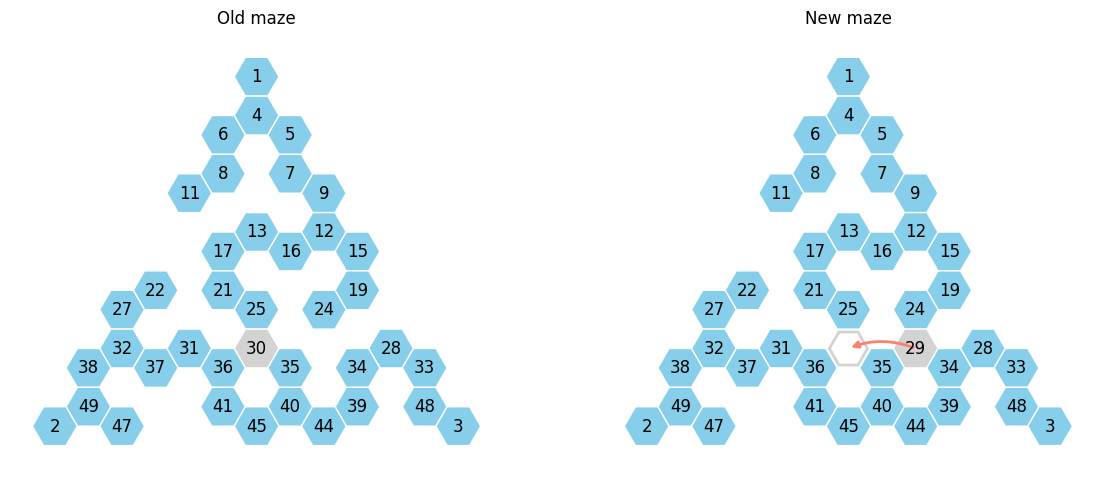

In [1]:
import sys
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")  # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import (
    plot_hex_maze,
    get_pairwise_distance_matrix,
    get_pairwise_distance_change,
    get_barrier_change,
    get_distance_change_blocks,
)

# A single-hue colormap for low-to-high values. The dark end stops short of full
# saturation so the black hex labels stay readable on the darkest hexes.
SEQUENTIAL_COLORMAP = matplotlib.colors.LinearSegmentedColormap.from_list(
    "purples_truncated", plt.get_cmap("Purples")([0.05 + 0.73 * i / 255 for i in range(256)])
)

# Load the barrier sequence database and grab 2 mazes that differ by one barrier
barrier_sequence_database = pd.read_pickle("../Barrier_Sequence_Databases/barrier_sequence_database.pkl")
sequence = barrier_sequence_database.iloc[3]["barrier_sequence"]
old_maze, new_maze = sequence[0], sequence[1]

old_maze, new_maze = '10,14,18,20,23,26,29,42,43,46', '10,14,18,20,23,26,30,42,43,46'

old_barrier, new_barrier = get_barrier_change(old_maze, new_maze)
print(f"The barrier on hex {old_barrier} moved to hex {new_barrier}")

# The hexes involved in the barrier change have no distance to compare across mazes.
# They are excluded from the analysis, and shown in grey on every maze plot below.
excluded_hexes = {old_barrier, new_barrier}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_hex_maze(
    old_maze,
    ax=axes[0],
    show_barriers=False,
    show_barrier_change=False,
    highlight_hexes=excluded_hexes,
    highlight_colors="lightgrey",
    outline_hexes={new_barrier},
    outline_colors="lightgrey",
)
axes[0].set_title("Old maze")
plot_hex_maze(
    new_maze,
    ax=axes[1],
    old_barrier=old_barrier,
    new_barrier=new_barrier,
    show_barriers=False,
    show_barrier_change=False,
    highlight_hexes=excluded_hexes,
    highlight_colors="lightgrey",
    outline_hexes={new_barrier},
    outline_colors="lightgrey",
)
axes[1].set_title("New maze")
plt.show()

## 2. Compute pairwise distances on each maze

`get_hex_distance` gives the distance between a single pair of hexes. To get all pairs at once, we go straight to the maze graph and use `nx.all_pairs_shortest_path_length`.

We only compare hexes that are open in both mazes (the old barrier and new barrier hexes have no distance to compare, so they are excluded)

38 hexes open in both mazes (excluding hexes 29 (old barrier) and 30 (new barrier))
343 of 703 hex pairs (49%) changed distance
The largest change for a single pair is 12 hexes


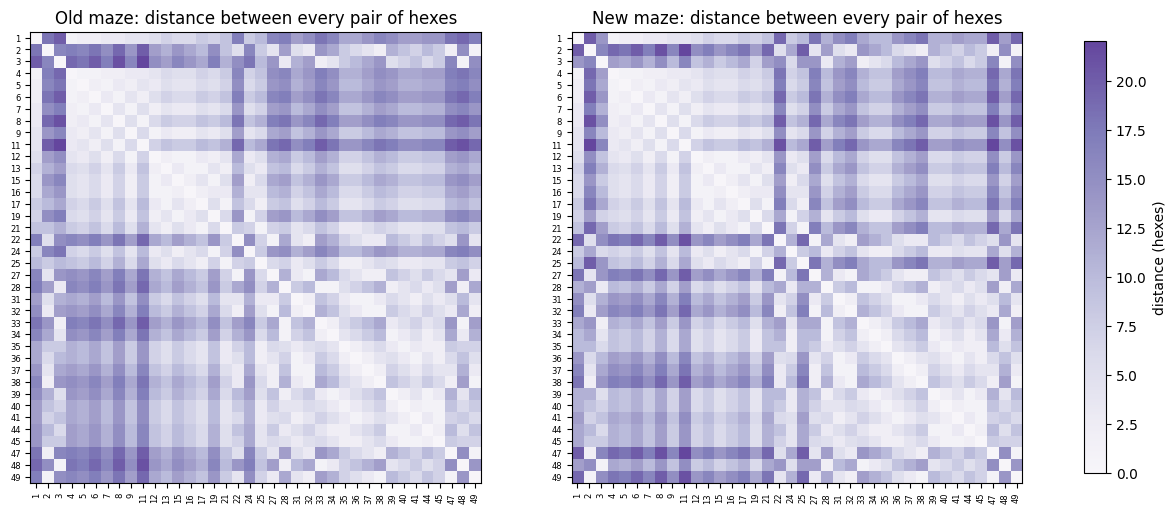

In [2]:
# Only hexes open in both mazes have a distance we can compare across mazes
distance_change = get_pairwise_distance_change(old_maze, new_maze)
shared_hexes = list(distance_change.index)
print(f"{len(shared_hexes)} hexes open in both mazes (excluding hexes {old_barrier} (old barrier) and {new_barrier} (new barrier))")

# Restrict each maze's distances to the shared hexes so all 3 matrices line up
old_distances = get_pairwise_distance_matrix(old_maze).loc[shared_hexes, shared_hexes]
new_distances = get_pairwise_distance_matrix(new_maze).loc[shared_hexes, shared_hexes]

num_pairs = len(shared_hexes) * (len(shared_hexes) - 1) // 2
num_changed_pairs = int((distance_change.values != 0).sum() // 2)
print(f"{num_changed_pairs} of {num_pairs} hex pairs ({num_changed_pairs / num_pairs:.0%}) changed distance")
print(f"The largest change for a single pair is {int(distance_change.abs().values.max())} hexes")


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Put both matrices on the same color scale so they are directly comparable
max_distance = max(old_distances.values.max(), new_distances.values.max())

for ax, distances, title in [
    (axes[0], old_distances, "Old maze"),
    (axes[1], new_distances, "New maze"),
]:
    image = ax.imshow(distances, cmap=SEQUENTIAL_COLORMAP, vmin=0, vmax=max_distance)
    ax.set_xticks(range(len(shared_hexes)), shared_hexes, fontsize=6, rotation=90)
    ax.set_yticks(range(len(shared_hexes)), shared_hexes, fontsize=6)
    ax.set_title(f"{title}: distance between every pair of hexes")

colorbar = fig.colorbar(image, ax=axes, shrink=0.8)
colorbar.set_label("distance (hexes)")
plt.show()

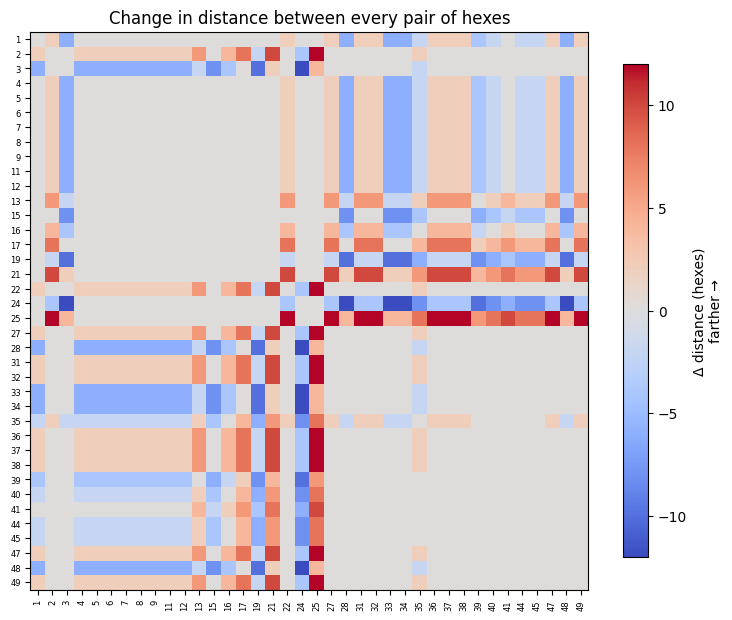

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))

# Center the diverging colormap on zero
largest_pair_change = distance_change.abs().values.max()

image = ax.imshow(
    distance_change, cmap="coolwarm", vmin=-largest_pair_change, vmax=largest_pair_change
)
ax.set_xticks(range(len(shared_hexes)), shared_hexes, fontsize=6, rotation=90)
ax.set_yticks(range(len(shared_hexes)), shared_hexes, fontsize=6)
ax.set_title("Change in distance between every pair of hexes")

colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("Δ distance (hexes)\nfarther →")
plt.show()

## 3. Summarize the change per hex

Each hex has 38 pairwise changes, one to every other shared hex. Four ways to collapse those into a single number per hex:

- **number of changed partners**: how many other hexes this hex changed distance to at all
- **mean absolute change**: how much this hex's distances were rearranged, regardless of direction
- **mean signed change**: whether this hex got closer to (negative) or farther from (positive) the rest of the maze
- **max absolute change**: this hex's single most-changed partner

The first three measure magnitude and broadly agree; the signed change measures direction instead, so it ranks hexes differently.

In [4]:
hex_distance_change = pd.DataFrame(
    {
        "num_changed_partners": (distance_change != 0).sum(axis=1),
        "mean_abs_change": distance_change.abs().mean(axis=1),
        "mean_signed_change": distance_change.mean(axis=1),
        "max_abs_change": distance_change.abs().max(axis=1),
    }
)
hex_distance_change.index.name = "hex"

# The hexes whose distances to the rest of the maze changed the most
hex_distance_change.sort_values("mean_abs_change", ascending=False).head(10)

,num_changed_partners,mean_abs_change,mean_signed_change,max_abs_change
hex,,,,
25,21,4.947368,4.947368,12
24,21,3.894737,-3.894737,12
21,21,3.842105,3.842105,10
19,21,2.789474,-2.789474,10
17,16,2.736842,2.736842,8
33,17,2.578947,-2.263158,12
34,17,2.578947,-2.263158,12
48,17,2.578947,-2.263158,12
3,17,2.578947,-2.263158,12


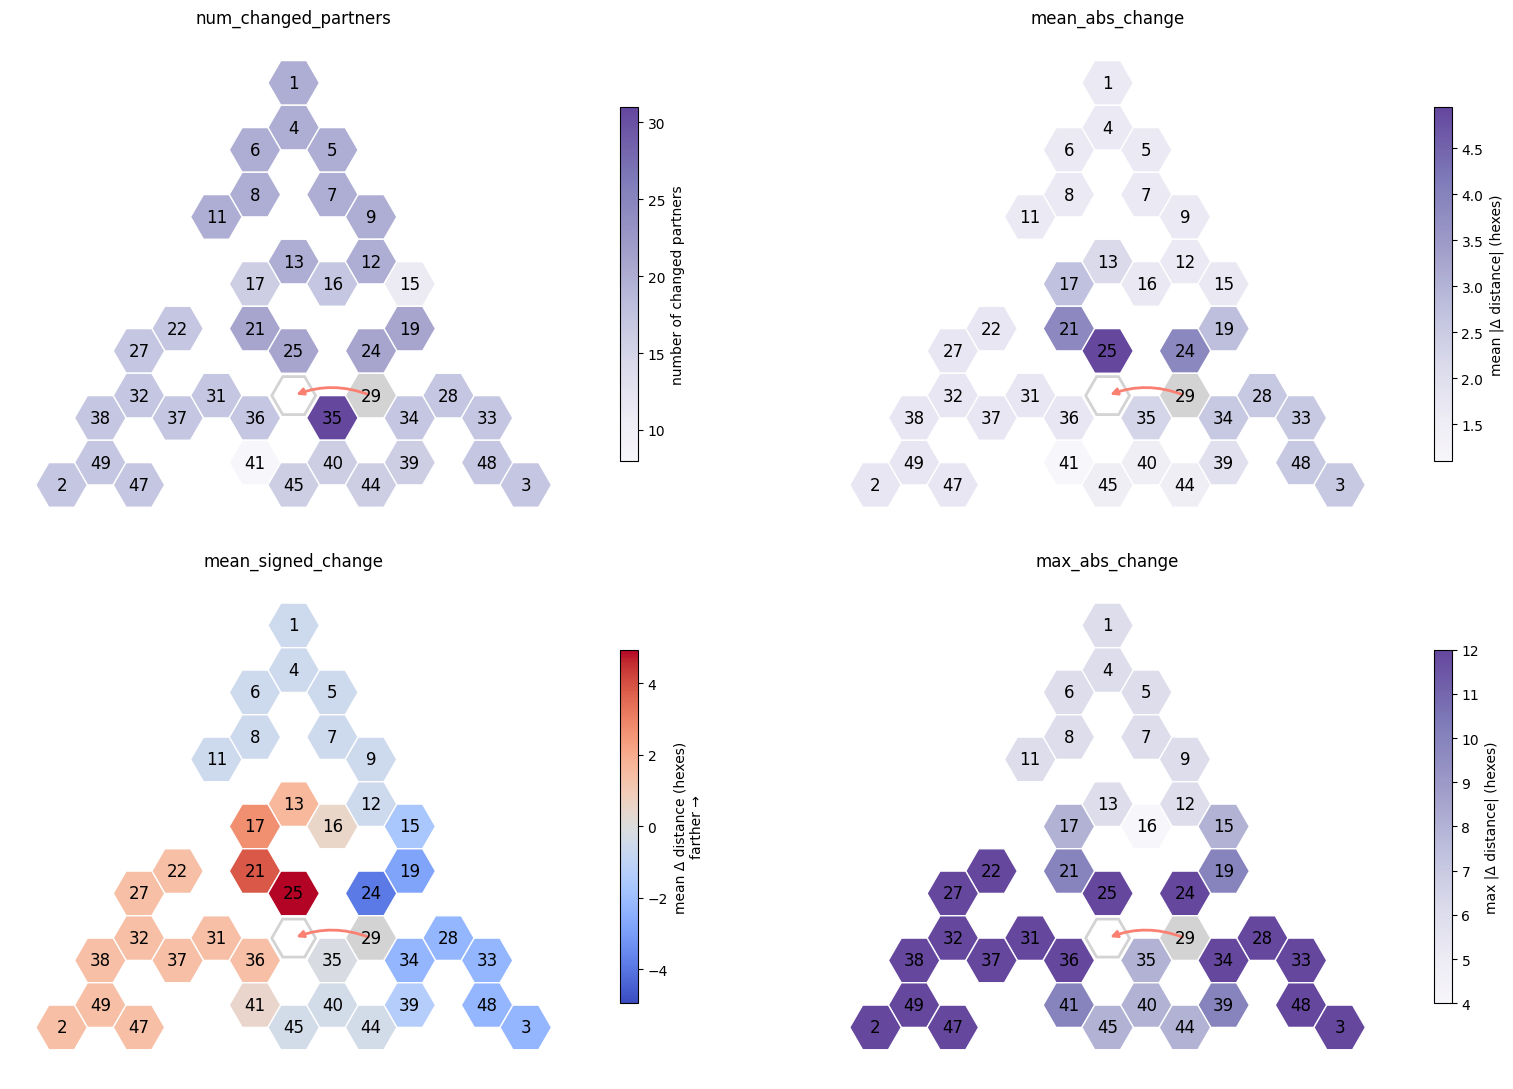

In [5]:
# Each metric, its colorbar label, colormap, and whether to center the colormap on zero
metrics_to_plot = [
    ("num_changed_partners", "number of changed partners", SEQUENTIAL_COLORMAP, False),
    ("mean_abs_change", "mean |Δ distance| (hexes)", SEQUENTIAL_COLORMAP, False),
    ("mean_signed_change", "mean Δ distance (hexes)\nfarther →", "coolwarm", True),
    ("max_abs_change", "max |Δ distance| (hexes)", SEQUENTIAL_COLORMAP, False),
]

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

for ax, (metric, label, colormap, center_on_zero) in zip(axes.flat, metrics_to_plot):
    values = hex_distance_change[metric].to_dict()

    # Diverging metrics are centered on zero so the color shows direction
    if center_on_zero:
        vmax = max(abs(value) for value in values.values())
        vmin = -vmax
    else:
        vmin, vmax = min(values.values()), max(values.values())

    plot_hex_maze(
        new_maze,
        ax=ax,
        old_barrier=old_barrier,
        new_barrier=new_barrier,
        show_barriers=False,
        show_barrier_change=False,
        highlight_hexes=excluded_hexes,
        highlight_colors="lightgrey",  # No data: not open in both mazes
        outline_hexes={new_barrier},
        outline_colors="lightgrey",  # Where the new barrier is
        color_by=values,
        colormap=colormap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(metric)

    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=colormap),
        ax=ax,
        shrink=0.7,
    )
    colorbar.set_label(label)

plt.tight_layout()
plt.show()

## 4. Change in distance to each reward port

The reference hexes we usually care about are the reward ports, since that is the distance the rat is working against. Taking the port's column of `distance_change` gives every hex's change in distance to that port. All 3 ports share a color scale so they are directly comparable: blue hexes got closer to that port, red hexes got farther from it.

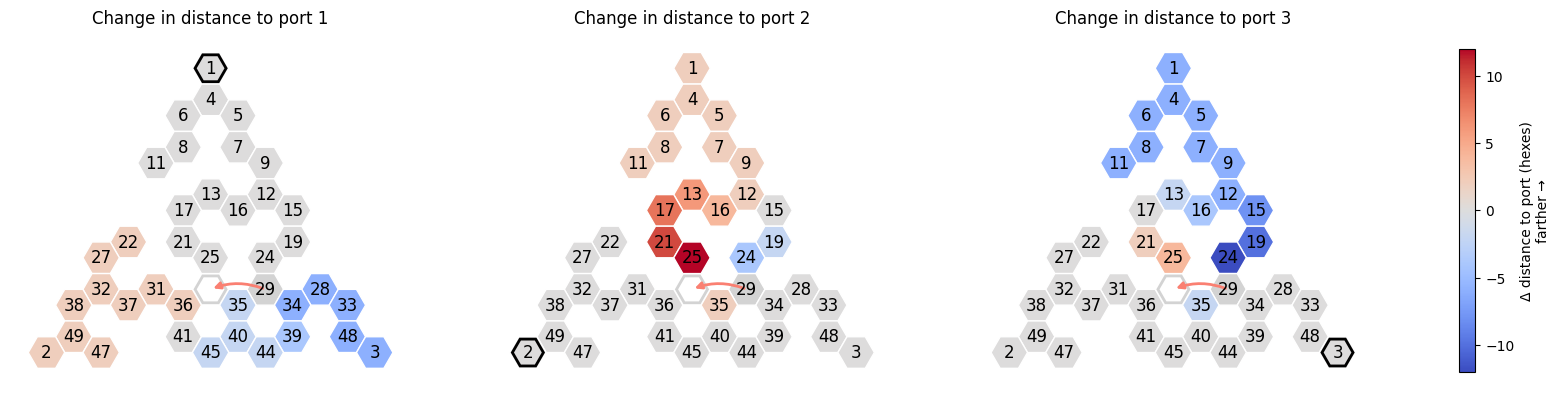

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Put all 3 ports on the same color scale so they are directly comparable
largest_change_to_ports = max(distance_change[port].abs().max() for port in (1, 2, 3))

for ax, port in zip(axes, (1, 2, 3)):
    plot_hex_maze(
        new_maze,
        ax=ax,
        old_barrier=old_barrier,
        new_barrier=new_barrier,
        show_barriers=False,
        show_barrier_change=False,
        highlight_hexes=excluded_hexes,
        highlight_colors="lightgrey",  # No data: not open in both mazes
        outline_hexes=[{port}, {new_barrier}],
        outline_colors=["black", "lightgrey"],
        color_by=distance_change[port].to_dict(),
        colormap="coolwarm",
        vmin=-largest_change_to_ports,
        vmax=largest_change_to_ports,
    )
    ax.set_title(f"Change in distance to port {port}")

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=-largest_change_to_ports, vmax=largest_change_to_ports),
        cmap="coolwarm",
    ),
    ax=axes,
    shrink=0.6,
)
colorbar.set_label("Δ distance to port (hexes)\nfarther →")
plt.show()

Combining a hex's change in distance to all 3 ports gives a single measure of how much the barrier change moved that hex relative to the reward ports. The magnitude and the direction answer different questions, so both are worth having:

- **mean absolute change to ports**: how much this hex's relationship to the reward ports was rearranged, whether it got closer to some and farther from others
- **mean signed change to ports**: whether this hex is now farther from reward overall (positive) or closer to it (negative)

A hex that moved 5 hexes closer to one port and 5 hexes farther from another scores high on the first and zero on the second.

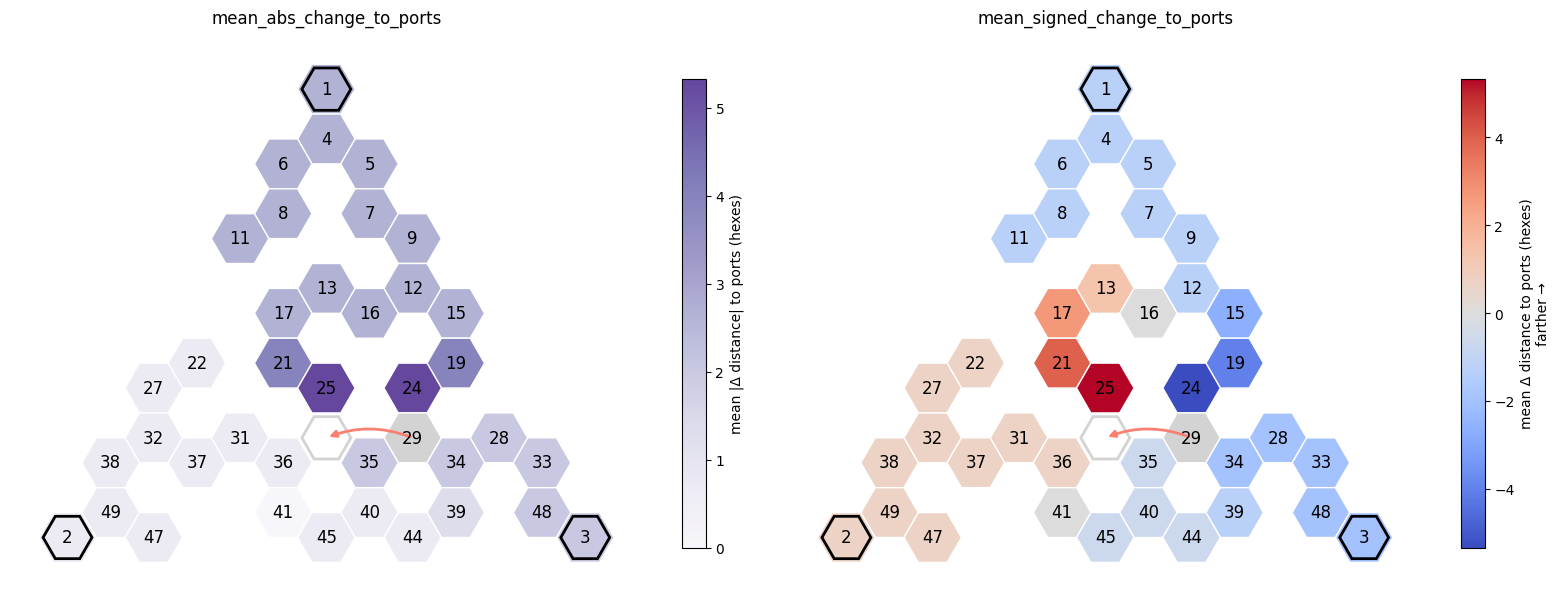

,num_changed_partners,mean_abs_change,mean_signed_change,max_abs_change,mean_abs_change_to_ports,mean_signed_change_to_ports
hex,,,,,,
25,21,4.947368,4.947368,12,5.333333,5.333333
24,21,3.894737,-3.894737,12,5.333333,-5.333333
21,21,3.842105,3.842105,10,4.000000,4.000000
19,21,2.789474,-2.789474,10,4.000000,-4.000000
12,20,1.631579,-0.578947,6,2.666667,-1.333333
17,16,2.736842,2.736842,8,2.666667,2.666667
16,17,1.684211,0.526316,4,2.666667,0.000000
15,11,1.684211,-1.684211,8,2.666667,-2.666667
13,20,2.157895,1.631579,6,2.666667,1.333333


In [7]:
# Combine each hex's change in distance to the 3 reward ports
port_changes = distance_change[[1, 2, 3]]
hex_distance_change["mean_abs_change_to_ports"] = port_changes.abs().mean(axis=1)
hex_distance_change["mean_signed_change_to_ports"] = port_changes.mean(axis=1)

combined_metrics_to_plot = [
    ("mean_abs_change_to_ports", "mean |Δ distance| to ports (hexes)", SEQUENTIAL_COLORMAP, False),
    ("mean_signed_change_to_ports", "mean Δ distance to ports (hexes)\nfarther →", "coolwarm", True),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (metric, label, colormap, center_on_zero) in zip(axes, combined_metrics_to_plot):
    values = hex_distance_change[metric].to_dict()

    # Diverging metrics are centered on zero so the color shows direction
    if center_on_zero:
        vmax = max(abs(value) for value in values.values())
        vmin = -vmax
    else:
        vmin, vmax = min(values.values()), max(values.values())

    plot_hex_maze(
        new_maze,
        ax=ax,
        old_barrier=old_barrier,
        new_barrier=new_barrier,
        show_barriers=False,
        show_barrier_change=False,
        highlight_hexes=excluded_hexes,
        highlight_colors="lightgrey",  # No data: not open in both mazes
        outline_hexes=[{1, 2, 3}, {new_barrier}],
        outline_colors=["black", "lightgrey"],
        color_by=values,
        colormap=colormap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(metric)

    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=colormap),
        ax=ax,
        shrink=0.7,
    )
    colorbar.set_label(label)

plt.tight_layout()
plt.show()

hex_distance_change.sort_values("mean_abs_change_to_ports", ascending=False).head(10)

## 5. Blocks of hexes that move together

The change matrix is not a smooth gradient over the maze: it is made of blocks. Grouping hexes by their entire row of `distance_change` collapses the matrix into a handful of blocks, where every hex in a block changed distance by the same amount to every hex outside it, and distances *within* a block did not change at all. The barrier change slides these blocks relative to each other rather than rearranging the maze hex by hex.

Blocks containing a single hex are hexes that moved on their own, which tend to lie on the re-routed corridor itself.

In [8]:
blocks = get_distance_change_blocks(old_maze, new_maze, sort_by="similarity")

print(f"{len(shared_hexes)} hexes fall into {len(blocks)} blocks that moved together:")
for block in blocks:
    if len(block) > 1:
        print(f"  {len(block):2d} hexes: {block}")
print(f"  {sum(len(block) == 1 for block in blocks)} single hexes: "
      f"{sorted(block[0] for block in blocks if len(block) == 1)}")

38 hexes fall into 15 blocks that moved together:
   9 hexes: [1, 4, 5, 6, 7, 8, 9, 11, 12]
   3 hexes: [40, 44, 45]
   5 hexes: [3, 28, 33, 34, 48]
  10 hexes: [2, 22, 27, 31, 32, 36, 37, 38, 47, 49]
  11 single hexes: [13, 15, 16, 17, 19, 21, 24, 25, 35, 39, 41]


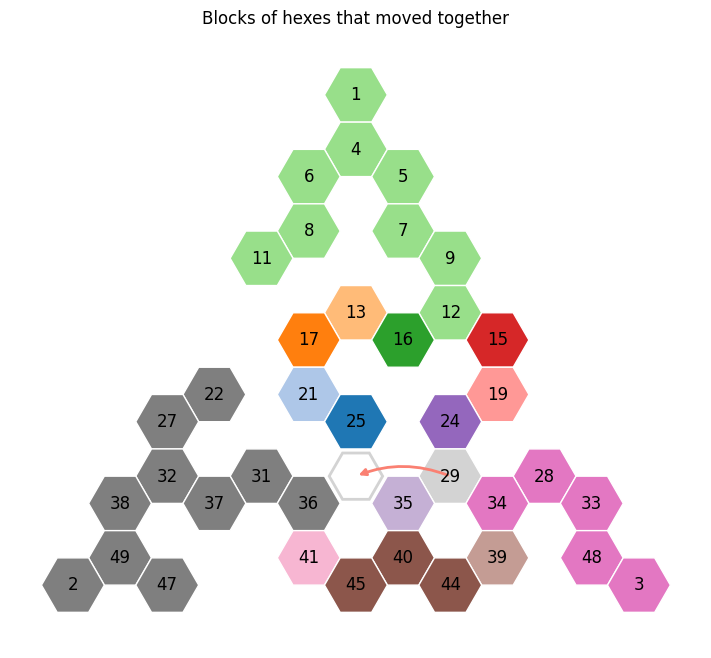

In [9]:
# Give each block its own color, and keep the no-data hexes grey
block_colors = [matplotlib.colormaps["tab20"](i % 20) for i in range(len(blocks))]

fig, ax = plt.subplots(figsize=(9, 8))
plot_hex_maze(
    new_maze,
    ax=ax,
    old_barrier=old_barrier,
    new_barrier=new_barrier,
    show_barriers=False,
    show_barrier_change=False,
    highlight_hexes=[set(block) for block in blocks] + [excluded_hexes],
    highlight_colors=block_colors + ["lightgrey"],  # No data: not open in both mazes
    outline_hexes={new_barrier},
    outline_colors="lightgrey",  # Where the new barrier is
)
ax.set_title("Blocks of hexes that moved together")
plt.show()

Sorting the change matrix so that hexes in the same block are adjacent makes the structure explicit: the zero blocks down the diagonal are the distances that did not change, and each off-diagonal block is a single constant value.

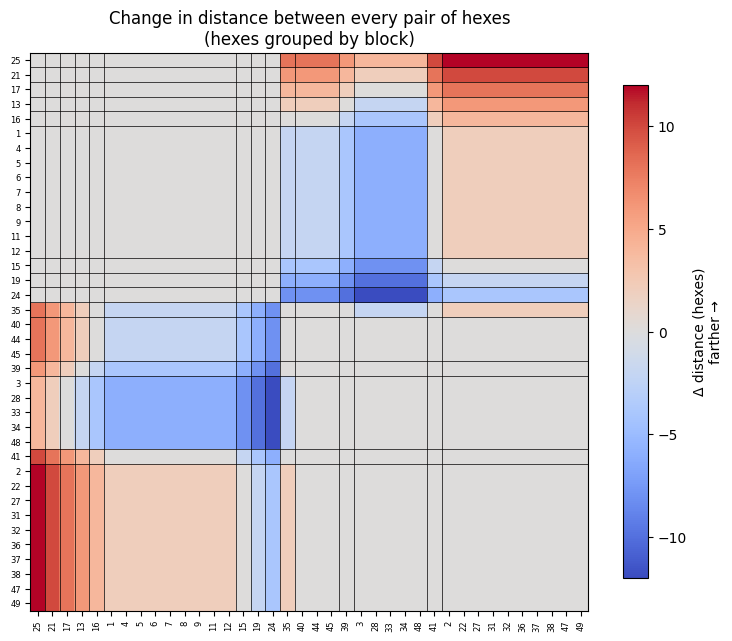

In [10]:
sorted_distance_change = get_pairwise_distance_change(old_maze, new_maze, sort_by_block="similarity")

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(
    sorted_distance_change, cmap="coolwarm", vmin=-largest_pair_change, vmax=largest_pair_change
)
ax.set_xticks(range(len(sorted_distance_change)), sorted_distance_change.index, fontsize=6, rotation=90)
ax.set_yticks(range(len(sorted_distance_change)), sorted_distance_change.index, fontsize=6)
ax.set_title("Change in distance between every pair of hexes\n(hexes grouped by block)")

# Mark where one block ends and the next begins
block_edges = pd.Series([len(block) for block in blocks]).cumsum()[:-1]
for edge in block_edges:
    ax.axhline(edge - 0.5, color="black", linewidth=0.5)
    ax.axvline(edge - 0.5, color="black", linewidth=0.5)

colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("Δ distance (hexes)\nfarther →")
plt.show()